# 1. Análisis exploratorio (EDA)

Responde las preguntas **1.1** y **1.2** de la prueba: (1) qué representa cada fila, (2) cómo separar la información en tablas,
(3) cómo se relacionan los indicadores con su catálogo, (4) cómo se relacionan los equipos con el catálogo de entornos.

No modifica ni guarda datos: solo lee el archivo original.

| Artefacto | Ruta |
|---|---|
| Entrada | `0_datos/KPIS_historico.xlsx` |


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

pd.set_option("display.max_colwidth", 70)

ARCHIVO = Path("../../0_datos/KPIS_historico.xlsx")
VERDE, NARANJA, MORADO, AZUL, GRIS = "#00c389", "#ff7f41", "#9063cd", "#59cbe8", "#9e9a99"

# Se lee todo como texto para ver los valores tal como vienen en el Excel
kpis = pd.read_excel(ARCHIVO, sheet_name="query", dtype=str)
cat_indicadores = pd.read_excel(ARCHIVO, sheet_name="catalogo_indicadores", dtype=str)
cat_entornos = pd.read_excel(ARCHIVO, sheet_name="catalogo_entornos", dtype=str)

# Un mismo equipo aparece escrito de varias formas (Equ00074 / EQU00074, EQU0024 / EQU00024): se unifica para contar equipos
kpis["codigo_equipo"] = kpis["Codigo_EQU"].str.upper().str.replace(r"^([A-Z]{3})0(\d{3})$", r"\g<1>00\2", regex=True)

for nombre, hoja in [("query", kpis), ("catalogo_indicadores", cat_indicadores), ("catalogo_entornos", cat_entornos)]:
    print(f"{nombre:<22} filas: {len(hoja):>6} | columnas: {list(hoja.columns)}")


query                  filas:  15188 | columnas: ['Frente', 'Corte', 'Codigo_EQU', 'EQU', 'Indicador', 'Resultado', 'Meta', 'Cumplimiento', 'codigo_equipo']
catalogo_indicadores   filas:     13 | columnas: ['Frente', 'Indicador', 'Definición (qué mide y para qué)', 'Unidad']
catalogo_entornos      filas:     64 | columnas: ['Codigo_EQU', 'Tipo', 'EQU', 'Codigo_Padre', 'Nombre_Padre']


## 1. ¿Qué representa cada fila?

Una fila de `query` es **el resultado de un indicador, para un equipo, en un mes**: el equipo `Codigo_EQU` obtuvo `Resultado` frente a una `Meta` en el `Corte` (mes AAAAMM), y eso equivale a un `Cumplimiento`.


In [2]:
display(kpis.sample(3, random_state=7))

llave = ["Corte", "Codigo_EQU", "Indicador"]
filas_unicas = kpis.drop(columns="codigo_equipo").drop_duplicates()
print("Filas totales:", len(kpis))
print("Filas repetidas exactamente igual:", len(kpis) - len(filas_unicas))
print("Combinaciones mes-equipo-indicador:", filas_unicas[llave].drop_duplicates().shape[0])
print("¿El frente cambia para un mismo indicador en un mismo mes y equipo?:",
      filas_unicas.groupby(llave)["Frente"].nunique().max() > 1)


,Frente,Corte,Codigo_EQU,EQU,Indicador,Resultado,Meta,Cumplimiento,codigo_equipo
13003,Experiencia,202603,EQU00061,Equipo 61,ICX,4.39,4,1.0975,EQU00061
8327,Modelos de trabajo y Agilidad,202502,EQU00072,NaN,Percepción,3.611111111111111,5,3.611111111111111,EQU00072
10566,TI,202506,EQU00044,NaN,Apps modernizadas,1,1,1,EQU00044


Filas totales: 15188
Filas repetidas exactamente igual: 2182
Combinaciones mes-equipo-indicador: 11961
¿El frente cambia para un mismo indicador en un mismo mes y equipo?: False


**Respuesta:** las columnas que identifican una fila son **`Corte` + `Codigo_EQU` + `Indicador`**. `Frente` depende del indicador y `EQU` (nombre) depende del código del equipo, por eso no hacen parte de la llave.
La llave casi se cumple: hay filas repetidas y algunos casos con más de un valor para la misma combinación (se cuantifican en `2_calidad_datos`).

## 2. ¿Cómo separar la información en tablas?

Hoy el Excel repite en cada fila el nombre del equipo y el frente. Separado en tablas quedaría así:

| Tabla | Una fila por | Columnas | Viene de |
|---|---|---|---|
| **Mediciones** (hechos) | mes × equipo × indicador | Corte, Codigo_EQU, Indicador, Resultado, Meta, Cumplimiento | hoja `query` |
| **Equipos** | equipo | Codigo_EQU, EQU, Tipo, Codigo_Padre | `catalogo_entornos` + nombres de `query` |
| **Entornos** | entorno o vicepresidencia | Codigo_Padre, Nombre_Padre, tipo (entorno / VP / sin entorno) | `catalogo_entornos` |
| **Indicadores** | indicador | Indicador, Frente, Definición, Unidad | `catalogo_indicadores` (+ los que faltan) |

Para que esto funcione, cada medición debe encontrar su indicador en el catálogo de indicadores y su equipo en el catálogo de entornos. Eso es lo que se valida a continuación.

## 3. Indicadores: ¿coinciden con el catálogo?


In [3]:
# Por indicador: cuántos equipos lo miden, en cuántos meses y si existe en el catálogo
por_indicador = (
    kpis.groupby("Indicador")
    .agg(frente=("Frente", "first"), equipos=("codigo_equipo", "nunique"), meses=("Corte", "nunique"), filas=("Corte", "size"))
    .reset_index()
)
nombres_catalogo = set(cat_indicadores["Indicador"])
# Sin tildes y en minúscula para detectar diferencias solo de escritura
def simplificar(texto):
    return texto.lower().replace("á", "a").replace("é", "e").replace("í", "i").replace("ó", "o").replace("ú", "u")

nombres_catalogo_simple = {simplificar(n) for n in nombres_catalogo}
por_indicador["estado"] = "No está en el catálogo"
por_indicador.loc[por_indicador["Indicador"].map(simplificar).isin(nombres_catalogo_simple), "estado"] = "En catálogo (escrito distinto)"
por_indicador.loc[por_indicador["Indicador"].isin(nombres_catalogo), "estado"] = "En catálogo (igual)"

print(por_indicador["estado"].value_counts().to_string())
print("\nFilas de la base según estado del indicador:")
print((por_indicador.groupby("estado")["filas"].sum() / len(kpis)).round(3).to_string())
display(por_indicador.sort_values(["estado", "equipos"], ascending=[True, False]))


estado
No está en el catálogo            14
En catálogo (igual)               10
En catálogo (escrito distinto)     1

Filas de la base según estado del indicador:
estado
En catálogo (escrito distinto)    0.027
En catálogo (igual)               0.428
No está en el catálogo            0.544


,Indicador,frente,equipos,meses,filas,estado
20,Pérdida esperada por fraude,Excelencia operativa,54,8,417,En catálogo (escrito distinto)
10,Frente Micro,Financiero,62,18,701,En catálogo (igual)
9,Frente Macro,Financiero,59,14,427,En catálogo (igual)
7,Disponibilidad,TI,58,32,2018,En catálogo (igual)
4,Calidad estructura funcional,Modeos de trabajo y Agilidad,57,8,417,En catálogo (igual)
1,Adopción controles ciberseguridad,Excelencia operativa,54,35,799,En catálogo (igual)
5,Cierre de vulnerabilidades,Excelencia operativa,49,17,618,En catálogo (igual)
21,Regulatorio,Regulatorio,49,32,644,En catálogo (igual)
16,Madurez de las aplicaciones,TI,40,3,155,En catálogo (igual)
12,ICX,Experiencia,26,7,429,En catálogo (igual)


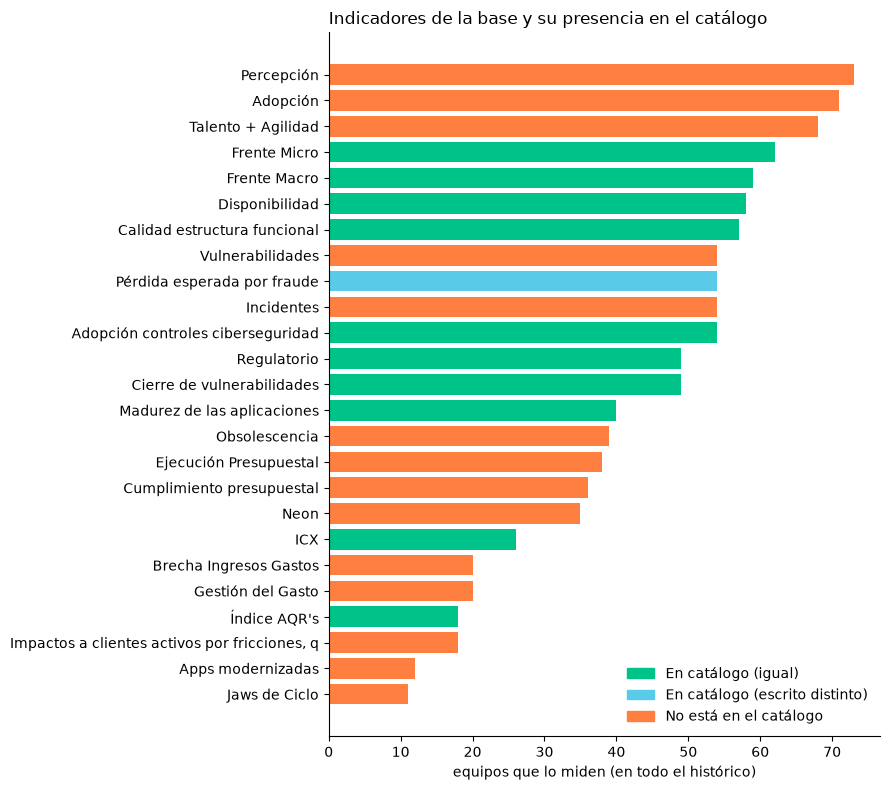

In [4]:
colores = {"En catálogo (igual)": VERDE, "En catálogo (escrito distinto)": AZUL, "No está en el catálogo": NARANJA}
orden = por_indicador.sort_values("equipos")
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(orden["Indicador"].str[:45], orden["equipos"], color=orden["estado"].map(colores))
ax.legend(handles=[Patch(color=c, label=e) for e, c in colores.items()], frameon=False, loc="lower right")
ax.set_xlabel("equipos que lo miden (en todo el histórico)")
ax.set_title("Indicadores de la base y su presencia en el catálogo", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### 3.1 ¿Hay indicadores del catálogo que ningún equipo mida?


In [5]:
indicadores_base_simple = set(kpis["Indicador"].map(simplificar))
sin_equipos = cat_indicadores[~cat_indicadores["Indicador"].map(simplificar).isin(indicadores_base_simple)]
display(sin_equipos[["Frente", "Indicador", "Definición (qué mide y para qué)", "Unidad"]])
print("¿Tienen exactamente la misma definición?:", sin_equipos["Definición (qué mide y para qué)"].nunique() == 1)


,Frente,Indicador,Definición (qué mide y para qué),Unidad
7,Modelos de trabajo y Agilidad,Adopción de la metodologia,"Consolida una mirada integral de la salud de los equipos, combinan...",Escala
8,Modeos de trabajo y Agilidad,Productividad,"Consolida una mirada integral de la salud de los equipos, combinan...",Porcentaje


¿Tienen exactamente la misma definición?: True


Los dos indicadores del catálogo sin mediciones comparten la misma definición: un índice que **combina adopción, percepción, calidad de la estructura funcional y productividad**.
En la base esos conceptos aparecen por separado (`Adopción`, `Percepción`, `Calidad estructura funcional`) y desde 2025 como `Talento + Agilidad`. Hipótesis: el catálogo documenta el índice consolidado y la base trae sus componentes. Debe confirmarse con el dueño del catálogo.

### 3.2 ¿El frente de cada indicador coincide con el del catálogo?


In [6]:
print("Frentes en la base:     ", sorted(kpis["Frente"].unique()))
print("Frentes en el catálogo: ", sorted(cat_indicadores["Frente"].unique()))
display(kpis.groupby("Frente")["Corte"].agg(primer_mes="min", ultimo_mes="max", filas="size"))


Frentes en la base:      ['Excelencia operativa', 'Experiencia', 'Financiero', 'Modelos de trabajo y Agilidad', 'Modeos de trabajo y Agilidad', 'Regulatorio', 'TI', 'Talento + Agilidad']
Frentes en el catálogo:  ['Excelencia operativa', 'Experiencia', 'Financiero', 'Modelos de trabajo y Agilidad', 'Modeos de trabajo y Agilidad', 'Regulatorio', 'TI']


,primer_mes,ultimo_mes,filas
Frente,,,
Excelencia operativa,202309,202608,2274
Experiencia,202601,202607,429
Financiero,202308,202606,2092
Modelos de trabajo y Agilidad,202501,202509,2826
Modeos de trabajo y Agilidad,202601,202608,417
Regulatorio,202310,202606,644
TI,202309,202608,3834
Talento + Agilidad,202301,202412,2672


El frente de agilidad aparece con **tres nombres que se suceden en el tiempo**: `Talento + Agilidad` (2023-2024), `Modelos de trabajo y Agilidad` (2025) y `Modeos de trabajo y Agilidad` (2026). El último es un error de escritura que **también está en el catálogo**, lo que sugiere que la base se alimenta del catálogo y hereda sus errores.

## 4. Equipos: ¿existen en el catálogo de entornos?

Antes de cruzar se revisa cómo están escritos los códigos de equipo.


In [7]:
print("Filas sin código de equipo:", kpis["Codigo_EQU"].isna().sum())
print("Formas distintas de escribir el código:", kpis["Codigo_EQU"].nunique())
print("Equipos reales (mayúsculas y 5 dígitos):", kpis["codigo_equipo"].nunique())
mal_escrito = kpis["Codigo_EQU"].notna() & (kpis["Codigo_EQU"] != kpis["codigo_equipo"])
print("Filas con el código mal escrito:", mal_escrito.sum())


Filas sin código de equipo: 36
Formas distintas de escribir el código: 146
Equipos reales (mayúsculas y 5 dígitos): 89
Filas con el código mal escrito: 325


### 4.1 Equipos fantasma: aparecen en la base pero no en el catálogo


In [8]:
catalogo = set(cat_entornos["Codigo_EQU"])
equipos = kpis.dropna(subset=["codigo_equipo"]).groupby("codigo_equipo").agg(
    primer_mes=("Corte", "min"), ultimo_mes=("Corte", "max"), filas=("Corte", "size"),
)
equipos["en_catalogo"] = equipos.index.isin(catalogo)
fantasmas = equipos[~equipos["en_catalogo"]]
fantasmas_activos = fantasmas[fantasmas["ultimo_mes"] >= "202601"]

print("Equipos en la base:", len(equipos), "| en catálogo:", equipos["en_catalogo"].sum(), "| fantasma:", len(fantasmas))
print("Filas de equipos fantasma:", fantasmas["filas"].sum(), f"({fantasmas['filas'].sum() / len(kpis):.1%} de la base)")
print("Fantasmas que dejaron de reportar antes de 2026 (equipos históricos):", len(fantasmas) - len(fantasmas_activos))
print("Fantasmas que siguen reportando en 2026 (faltan en el catálogo):", len(fantasmas_activos))
display(fantasmas_activos.sort_values("filas", ascending=False))


Equipos en la base: 89 | en catálogo: 63 | fantasma: 26
Filas de equipos fantasma: 1473 (9.7% de la base)
Fantasmas que dejaron de reportar antes de 2026 (equipos históricos): 18
Fantasmas que siguen reportando en 2026 (faltan en el catálogo): 8


,primer_mes,ultimo_mes,filas,en_catalogo
codigo_equipo,,,,
EQU00069,202301,202607,234,False
EQU00065,202301,202607,208,False
EQU00064,202301,202607,151,False
EQU00031,202301,202602,136,False
EQU00079,202401,202608,129,False
EQU00071,202301,202608,119,False
EQU00060,202301,202607,75,False
EQU00086,202608,202608,1,False


### 4.2 Equipos del catálogo sin mediciones


In [9]:
sin_mediciones = cat_entornos[~cat_entornos["Codigo_EQU"].isin(equipos.index)]
display(sin_mediciones)


,Codigo_EQU,Tipo,EQU,Codigo_Padre,Nombre_Padre
14,EQU00023,EQU,Equipo 23,VPX0008,Vicepresidencia 8


### 4.3 ¿A qué entorno pertenece cada equipo del catálogo?


In [10]:
cat_entornos["tipo_padre"] = "Sin entorno"
cat_entornos.loc[cat_entornos["Codigo_Padre"].str.startswith("ENX"), "tipo_padre"] = "Entorno"
cat_entornos.loc[cat_entornos["Codigo_Padre"].str.startswith("VPX"), "tipo_padre"] = "Vicepresidencia"

resumen_padres = cat_entornos.groupby("tipo_padre").agg(equipos=("Codigo_EQU", "size"), padres=("Codigo_Padre", "nunique"))
display(resumen_padres)
equipos_por_entorno = cat_entornos[cat_entornos["tipo_padre"] == "Entorno"].groupby("Nombre_Padre").size()
print("Equipos por entorno -> mínimo:", equipos_por_entorno.min(), "| mediana:", equipos_por_entorno.median(),
      "| máximo:", equipos_por_entorno.max(), "| entornos con 1 solo equipo:", (equipos_por_entorno == 1).sum())


,equipos,padres
tipo_padre,,
Entorno,50,16
Sin entorno,2,2
Vicepresidencia,12,8


Equipos por entorno -> mínimo: 1 | mediana: 3.0 | máximo: 10 | entornos con 1 solo equipo: 2


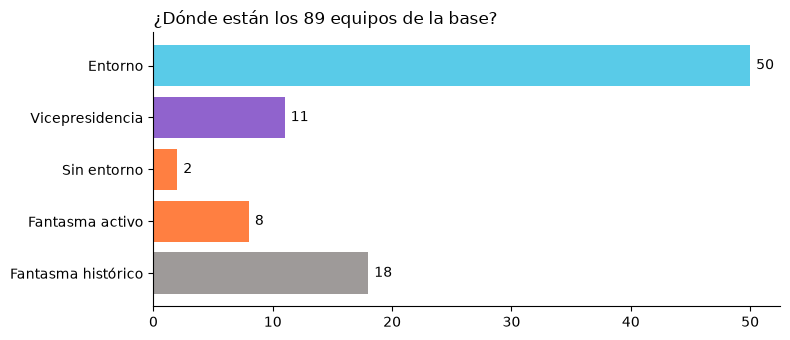

In [11]:
# Resumen visual: ubicación de los equipos de la base
equipos["ubicacion"] = equipos.index.map(cat_entornos.set_index("Codigo_EQU")["tipo_padre"])
equipos.loc[~equipos["en_catalogo"] & (equipos["ultimo_mes"] >= "202601"), "ubicacion"] = "Fantasma activo"
equipos.loc[~equipos["en_catalogo"] & (equipos["ultimo_mes"] < "202601"), "ubicacion"] = "Fantasma histórico"
conteo = equipos["ubicacion"].value_counts().reindex(["Entorno", "Vicepresidencia", "Sin entorno", "Fantasma activo", "Fantasma histórico"])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(conteo.index[::-1], conteo.values[::-1], color=[GRIS, NARANJA, NARANJA, MORADO, AZUL])
for i, v in enumerate(conteo.values[::-1]):
    ax.text(v + 0.5, i, str(v), va="center")
ax.set_title(f"¿Dónde están los {len(equipos)} equipos de la base?", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## Resumen

**1.1** Cada fila es el resultado mensual de un indicador para un equipo; la identifican `Corte` + `Codigo_EQU` + `Indicador`. Se propone separar en Mediciones, Equipos, Entornos e Indicadores.

**1.2** Los catálogos **no describen completamente la base**:
- **Indicadores:** solo 10 de 25 coinciden exactamente con el catálogo (11 si se ignoran tildes). Los 14 restantes, más de la mitad de las filas, no tienen definición ni unidad oficial. Hay 2 indicadores del catálogo que ningún equipo mide (probablemente el índice consolidado de agilidad). El frente de agilidad tiene 3 nombres.
- **Equipos:** el código de equipo aparece escrito de 146 formas distintas para solo 89 equipos reales (minúsculas, dígitos de menos). De esos 89, **63 están en el catálogo y 26 son equipos fantasma**: 18 son históricos (dejaron de reportar) y 8 siguen activos sin estar en el catálogo. 1 equipo del catálogo no tiene mediciones.
- **Entornos:** el catálogo mezcla entornos (50 equipos), vicepresidencias (12) y equipos marcados "sin entorno" (2); varios entornos tienen un solo equipo.
